## MY Car Selling Price Prediction

In [2]:
!pip install ydata_profiling

  Using cached multimethod-1.12-py3-none-any.whl.metadata (9.6 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.0 MB 7.1 MB/s eta 0:00:01
   --------- ------------------------------ 1.8/8.0 MB 7.2 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.0 MB 6.1 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.0 MB 6.3 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 6.5 MB/s  0:00:01
Using cached multimethod-1.12-py3-none-any.whl (10 kB)
   ---------------------------------------- 0.0/678.1 kB ? eta -:--:--
   ---------------------------------------- 678.1/678.1 kB 6.2 MB/s  0:00:00
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------- ----------------------- 1.3/3.1 MB 7.2 MB/s

  You can safely remove it manually.


In [3]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

%matplotlib inline
sns.set()

In [3]:
df = pd.read_csv("reg_cars_selling.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [5]:
df.shape

(8128, 13)

### name

In [7]:
df["name"]

0             Maruti Swift Dzire VDI
1       Skoda Rapid 1.5 TDI Ambition
2           Honda City 2017-2020 EXi
3          Hyundai i20 Sportz Diesel
4             Maruti Swift VXI BSIII
                    ...             
8123               Hyundai i20 Magna
8124           Hyundai Verna CRDi SX
8125          Maruti Swift Dzire ZDi
8126                 Tata Indigo CR4
8127                 Tata Indigo CR4
Name: name, Length: 8128, dtype: object

In [8]:
df["name"].nunique()

2058

In [9]:
df["name"].unique()

array(['Maruti Swift Dzire VDI', 'Skoda Rapid 1.5 TDI Ambition',
       'Honda City 2017-2020 EXi', ..., 'Tata Nexon 1.5 Revotorq XT',
       'Ford Freestyle Titanium Plus Diesel BSIV',
       'Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV'], dtype=object)

In [10]:
# to change the columns order in the data frame
df[["company", "model"]] = df["name"].str.split(" ",n = 1,  expand = True )

In [11]:
df.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,company,model
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,Maruti,Swift Dzire VDI
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,Skoda,Rapid 1.5 TDI Ambition


In [12]:
df.drop(columns = ["name"],inplace = True)
cols = df.columns.tolist()
cols = cols[-2:] + cols[:-2]
df = df[cols]
df.head(1)

,company,model,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti,Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0


In [13]:
df["company"].describe()

count       8128
unique        32
top       Maruti
freq        2448
Name: company, dtype: object

In [14]:
df["company"].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Fiat', 'Datsun', 'Jeep',
       'Mercedes-Benz', 'Mitsubishi', 'Audi', 'Volkswagen', 'BMW',
       'Nissan', 'Lexus', 'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo',
       'Kia', 'Force', 'Ambassador', 'Ashok', 'Isuzu', 'Opel', 'Peugeot'],
      dtype=object)

### year

In [16]:
df["year"]

0       2014
1       2014
2       2006
3       2010
4       2007
        ... 
8123    2013
8124    2007
8125    2009
8126    2013
8127    2013
Name: year, Length: 8128, dtype: int64

In [17]:
df["year"].unique()

array([2014, 2006, 2010, 2007, 2017, 2001, 2011, 2013, 2005, 2009, 2016,
       2012, 2002, 2015, 2018, 2003, 2019, 2008, 2020, 1999, 2000, 1983,
       2004, 1996, 1994, 1995, 1998, 1997, 1991], dtype=int64)

In [18]:
df["year"].describe()

count    8128.000000
mean     2013.804011
std         4.044249
min      1983.000000
25%      2011.000000
50%      2015.000000
75%      2017.000000
max      2020.000000
Name: year, dtype: float64

### selling_price

In [20]:
df["selling_price"]

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8123    320000
8124    135000
8125    382000
8126    290000
8127    290000
Name: selling_price, Length: 8128, dtype: int64

In [21]:
df["selling_price"].describe()

count    8.128000e+03
mean     6.382718e+05
std      8.062534e+05
min      2.999900e+04
25%      2.549990e+05
50%      4.500000e+05
75%      6.750000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

### km_driven

In [23]:
df["km_driven"]

0       145500
1       120000
2       140000
3       127000
4       120000
         ...  
8123    110000
8124    119000
8125    120000
8126     25000
8127     25000
Name: km_driven, Length: 8128, dtype: int64

In [24]:
df["km_driven"].describe()

count    8.128000e+03
mean     6.981951e+04
std      5.655055e+04
min      1.000000e+00
25%      3.500000e+04
50%      6.000000e+04
75%      9.800000e+04
max      2.360457e+06
Name: km_driven, dtype: float64

### fuel

In [26]:
df["fuel"]

0       Diesel
1       Diesel
2       Petrol
3       Diesel
4       Petrol
         ...  
8123    Petrol
8124    Diesel
8125    Diesel
8126    Diesel
8127    Diesel
Name: fuel, Length: 8128, dtype: object

In [27]:
df["fuel"].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [28]:
df["fuel"].describe()

count       8128
unique         4
top       Diesel
freq        4402
Name: fuel, dtype: object

In [29]:
df["fuel"].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

### seller_type

In [31]:
df["seller_type"]

0       Individual
1       Individual
2       Individual
3       Individual
4       Individual
           ...    
8123    Individual
8124    Individual
8125    Individual
8126    Individual
8127    Individual
Name: seller_type, Length: 8128, dtype: object

In [32]:
df["seller_type"].value_counts()

seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

In [33]:
df["seller_type"].describe()

count           8128
unique             3
top       Individual
freq            6766
Name: seller_type, dtype: object

### transmission

In [35]:
df["transmission"]

0       Manual
1       Manual
2       Manual
3       Manual
4       Manual
         ...  
8123    Manual
8124    Manual
8125    Manual
8126    Manual
8127    Manual
Name: transmission, Length: 8128, dtype: object

In [36]:
df["transmission"].value_counts()

transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

In [37]:
df["transmission"].describe()

count       8128
unique         2
top       Manual
freq        7078
Name: transmission, dtype: object

### owner

In [39]:
df["owner"]

0                First Owner
1               Second Owner
2                Third Owner
3                First Owner
4                First Owner
                ...         
8123             First Owner
8124    Fourth & Above Owner
8125             First Owner
8126             First Owner
8127             First Owner
Name: owner, Length: 8128, dtype: object

In [40]:
df["owner"].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [41]:
df["owner"].describe()

count            8128
unique              5
top       First Owner
freq             5289
Name: owner, dtype: object

### mileage

In [43]:
df["mileage"]

0        23.4 kmpl
1       21.14 kmpl
2        17.7 kmpl
3        23.0 kmpl
4        16.1 kmpl
           ...    
8123     18.5 kmpl
8124     16.8 kmpl
8125     19.3 kmpl
8126    23.57 kmpl
8127    23.57 kmpl
Name: mileage, Length: 8128, dtype: object

In [44]:
df["mileage"].value_counts()

mileage
18.9 kmpl      225
19.7 kmpl      173
18.6 kmpl      164
21.1 kmpl      157
17.0 kmpl      133
              ... 
16.34 kmpl       1
19.69 kmpl       1
20.88 km/kg      1
17.8 km/kg       1
16.51 kmpl       1
Name: count, Length: 393, dtype: int64

In [45]:
df["mileage"].describe()

count          7907
unique          393
top       18.9 kmpl
freq            225
Name: mileage, dtype: object

In [46]:
df["mileage"].unique()

array(['23.4 kmpl', '21.14 kmpl', '17.7 kmpl', '23.0 kmpl', '16.1 kmpl',
       '20.14 kmpl', '17.3 km/kg', '23.59 kmpl', '20.0 kmpl',
       '19.01 kmpl', '17.3 kmpl', '19.3 kmpl', nan, '18.9 kmpl',
       '18.15 kmpl', '24.52 kmpl', '19.7 kmpl', '22.54 kmpl', '21.0 kmpl',
       '25.5 kmpl', '26.59 kmpl', '21.5 kmpl', '20.3 kmpl', '21.4 kmpl',
       '24.7 kmpl', '18.2 kmpl', '16.8 kmpl', '24.3 kmpl', '14.0 kmpl',
       '18.6 kmpl', '33.44 km/kg', '23.95 kmpl', '17.0 kmpl',
       '20.63 kmpl', '13.93 kmpl', '16.0 kmpl', '17.8 kmpl', '18.5 kmpl',
       '12.55 kmpl', '12.99 kmpl', '14.8 kmpl', '13.5 kmpl', '26.0 kmpl',
       '20.65 kmpl', '27.3 kmpl', '11.36 kmpl', '17.68 kmpl',
       '14.28 kmpl', '18.53 kmpl', '14.84 kmpl', '21.12 kmpl',
       '20.36 kmpl', '21.27 kmpl', '18.16 kmpl', '22.0 kmpl', '25.1 kmpl',
       '20.51 kmpl', '21.66 kmpl', '25.2 kmpl', '22.9 kmpl', '16.02 kmpl',
       '20.54 kmpl', '22.77 kmpl', '15.71 kmpl', '23.1 kmpl',
       '19.02 kmpl', '19.81 kmpl'

In [47]:
#since mileage has two units, to keep it consistent, we will convert the km/kg to km/l
def mileage_convert(x):
    if type(x) == str:
        if x.split()[-1] == 'km/kg':
            return float(x.split()[0])*1.40 #formula
        elif x.split()[-1] == 'kmpl':
            return float(x.split()[0])
    else:
        return x
    
df['mileage'].apply(mileage_convert)

0       23.40
1       21.14
2       17.70
3       23.00
4       16.10
        ...  
8123    18.50
8124    16.80
8125    19.30
8126    23.57
8127    23.57
Name: mileage, Length: 8128, dtype: float64

In [48]:
df['mileage(km/l)'] = df['mileage'].apply(mileage_convert)

In [49]:
df.head(2)

,company,model,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,mileage(km/l)
0,Maruti,Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,23.40
1,Skoda,Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,21.14


### engine

In [51]:
df["engine"]

0       1248 CC
1       1498 CC
2       1497 CC
3       1396 CC
4       1298 CC
         ...   
8123    1197 CC
8124    1493 CC
8125    1248 CC
8126    1396 CC
8127    1396 CC
Name: engine, Length: 8128, dtype: object

In [52]:
df["engine"].describe()

count        7907
unique        121
top       1248 CC
freq         1017
Name: engine, dtype: object

In [53]:
df["engine"].unique()

array(['1248 CC', '1498 CC', '1497 CC', '1396 CC', '1298 CC', '1197 CC',
       '1061 CC', '796 CC', '1364 CC', '1399 CC', '1461 CC', '993 CC',
       nan, '1198 CC', '1199 CC', '998 CC', '1591 CC', '2179 CC',
       '1368 CC', '2982 CC', '2494 CC', '2143 CC', '2477 CC', '1462 CC',
       '2755 CC', '1968 CC', '1798 CC', '1196 CC', '1373 CC', '1598 CC',
       '1998 CC', '1086 CC', '1194 CC', '1172 CC', '1405 CC', '1582 CC',
       '999 CC', '2487 CC', '1999 CC', '3604 CC', '2987 CC', '1995 CC',
       '1451 CC', '1969 CC', '2967 CC', '2497 CC', '1797 CC', '1991 CC',
       '2362 CC', '1493 CC', '1599 CC', '1341 CC', '1794 CC', '799 CC',
       '1193 CC', '2696 CC', '1495 CC', '1186 CC', '1047 CC', '2498 CC',
       '2956 CC', '2523 CC', '1120 CC', '624 CC', '1496 CC', '1984 CC',
       '2354 CC', '814 CC', '793 CC', '1799 CC', '936 CC', '1956 CC',
       '1997 CC', '1499 CC', '1948 CC', '2997 CC', '2489 CC', '2499 CC',
       '2609 CC', '2953 CC', '1150 CC', '1994 CC', '1388 CC', '152

In [54]:
df["engine"].str.replace(" CC","").astype("float")

0       1248.0
1       1498.0
2       1497.0
3       1396.0
4       1298.0
         ...  
8123    1197.0
8124    1493.0
8125    1248.0
8126    1396.0
8127    1396.0
Name: engine, Length: 8128, dtype: float64

In [55]:
df["engine(CC)"] = df["engine"].str.replace(" CC","").astype("float")

In [56]:
df.head(1)

,company,model,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,mileage(km/l),engine(CC)
0,Maruti,Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,23.4,1248.0


In [57]:
df["max_power"]

0           74 bhp
1       103.52 bhp
2           78 bhp
3           90 bhp
4         88.2 bhp
           ...    
8123     82.85 bhp
8124       110 bhp
8125      73.9 bhp
8126        70 bhp
8127        70 bhp
Name: max_power, Length: 8128, dtype: object

In [58]:
df["max_power"].describe()

count       7913
unique       322
top       74 bhp
freq         377
Name: max_power, dtype: object

In [59]:
df["max_power"].unique()

array(['74 bhp', '103.52 bhp', '78 bhp', '90 bhp', '88.2 bhp',
       '81.86 bhp', '57.5 bhp', '37 bhp', '67.1 bhp', '68.1 bhp',
       '108.45 bhp', '60 bhp', '73.9 bhp', nan, '67 bhp', '82 bhp',
       '88.5 bhp', '46.3 bhp', '88.73 bhp', '64.1 bhp', '98.6 bhp',
       '88.8 bhp', '83.81 bhp', '83.1 bhp', '47.3 bhp', '73.8 bhp',
       '34.2 bhp', '35 bhp', '81.83 bhp', '40.3 bhp', '121.3 bhp',
       '138.03 bhp', '160.77 bhp', '117.3 bhp', '116.3 bhp', '83.14 bhp',
       '67.05 bhp', '168.5 bhp', '100 bhp', '120.7 bhp', '98.63 bhp',
       '175.56 bhp', '103.25 bhp', '171.5 bhp', '100.6 bhp', '174.33 bhp',
       '187.74 bhp', '170 bhp', '78.9 bhp', '88.76 bhp', '86.8 bhp',
       '108.495 bhp', '108.62 bhp', '93.7 bhp', '103.6 bhp', '98.59 bhp',
       '189 bhp', '67.04 bhp', '68.05 bhp', '58.2 bhp', '82.85 bhp',
       '81.80 bhp', '73 bhp', '120 bhp', '94.68 bhp', '160 bhp', '65 bhp',
       '155 bhp', '69.01 bhp', '126.32 bhp', '138.1 bhp', '83.8 bhp',
       '126.2 bhp', '98.

In [60]:
df["max_power(bhp)"] = df["max_power"].str.split(" ").str.get(0)

In [61]:
df.loc[df["max_power(bhp)"] == "" ]

,company,model,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,mileage(km/l),engine(CC),max_power(bhp)
4933,Maruti,Omni CNG,2000,80000,100000,CNG,Individual,Manual,Second Owner,10.9 km/kg,796 CC,bhp,NaN,8.0,15.26,796.0,


In [62]:
df.loc[df["max_power(bhp)"] == "" ,"max_power(bhp)"]

4933    
Name: max_power(bhp), dtype: object

In [63]:
df.loc[df["max_power(bhp)"] == "" ,"max_power(bhp)"] = np.nan

In [64]:
df.iloc[4933 ]

company                 Maruti
model                 Omni CNG
year                      2000
selling_price            80000
km_driven               100000
fuel                       CNG
seller_type         Individual
transmission            Manual
owner             Second Owner
mileage             10.9 km/kg
engine                  796 CC
max_power                  bhp
torque                     NaN
seats                      8.0
mileage(km/l)            15.26
engine(CC)               796.0
max_power(bhp)             NaN
Name: 4933, dtype: object

In [65]:
df["max_power(bhp)"] = df["max_power(bhp)"].astype("float")

### torque

In [67]:
df["torque"]

0                  190Nm@ 2000rpm
1             250Nm@ 1500-2500rpm
2           12.7@ 2,700(kgm@ rpm)
3        22.4 kgm at 1750-2750rpm
4           11.5@ 4,500(kgm@ rpm)
                  ...            
8123             113.7Nm@ 4000rpm
8124    24@ 1,900-2,750(kgm@ rpm)
8125               190Nm@ 2000rpm
8126          140Nm@ 1800-3000rpm
8127          140Nm@ 1800-3000rpm
Name: torque, Length: 8128, dtype: object

In [68]:
df["torque"].unique()

array(['190Nm@ 2000rpm', '250Nm@ 1500-2500rpm', '12.7@ 2,700(kgm@ rpm)',
       '22.4 kgm at 1750-2750rpm', '11.5@ 4,500(kgm@ rpm)',
       '113.75nm@ 4000rpm', '7.8@ 4,500(kgm@ rpm)', '59Nm@ 2500rpm',
       '170Nm@ 1800-2400rpm', '160Nm@ 2000rpm', '248Nm@ 2250rpm',
       '78Nm@ 4500rpm', nan, '84Nm@ 3500rpm', '115Nm@ 3500-3600rpm',
       '200Nm@ 1750rpm', '62Nm@ 3000rpm', '219.7Nm@ 1500-2750rpm',
       '114Nm@ 3500rpm', '115Nm@ 4000rpm', '69Nm@ 3500rpm',
       '172.5Nm@ 1750rpm', '6.1kgm@ 3000rpm', '114.7Nm@ 4000rpm',
       '60Nm@ 3500rpm', '90Nm@ 3500rpm', '151Nm@ 4850rpm',
       '104Nm@ 4000rpm', '320Nm@ 1700-2700rpm', '250Nm@ 1750-2500rpm',
       '145Nm@ 4600rpm', '146Nm@ 4800rpm', '343Nm@ 1400-3400rpm',
       '200Nm@ 1400-3400rpm', '200Nm@ 1250-4000rpm',
       '400Nm@ 2000-2500rpm', '138Nm@ 4400rpm', '360Nm@ 1200-3400rpm',
       '200Nm@ 1200-3600rpm', '380Nm@ 1750-2500rpm', '173Nm@ 4000rpm',
       '400Nm@ 1750-3000rpm', '400Nm@ 1400-2800rpm',
       '200Nm@ 1750-3000rp

In [69]:
# have alot of problem so I Drop it
df = df.drop(columns= "torque")

In [70]:
df.head(1)

,company,model,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,mileage(km/l),engine(CC),max_power(bhp)
0,Maruti,Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0,23.4,1248.0,74.0


### seat

In [72]:
df["seats"]

0       5.0
1       5.0
2       5.0
3       5.0
4       5.0
       ... 
8123    5.0
8124    5.0
8125    5.0
8126    5.0
8127    5.0
Name: seats, Length: 8128, dtype: float64

In [73]:
df["seats"].describe()

count    7907.000000
mean        5.416719
std         0.959588
min         2.000000
25%         5.000000
50%         5.000000
75%         5.000000
max        14.000000
Name: seats, dtype: float64

In [74]:
df.columns

Index(['company', 'model', 'year', 'selling_price', 'km_driven', 'fuel',
       'seller_type', 'transmission', 'owner', 'mileage', 'engine',
       'max_power', 'seats', 'mileage(km/l)', 'engine(CC)', 'max_power(bhp)'],
      dtype='object')

In [75]:
df = df.drop(columns= ['mileage', 'engine','max_power'])

In [76]:
df.columns

Index(['company', 'model', 'year', 'selling_price', 'km_driven', 'fuel',
       'seller_type', 'transmission', 'owner', 'seats', 'mileage(km/l)',
       'engine(CC)', 'max_power(bhp)'],
      dtype='object')

In [77]:
cols = df.columns.tolist()

In [78]:
cols

['company',
 'model',
 'year',
 'selling_price',
 'km_driven',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'seats',
 'mileage(km/l)',
 'engine(CC)',
 'max_power(bhp)']

In [79]:
cols_new = cols[:-4] + cols[-3:] + cols[-4:-3]
cols_new

['company',
 'model',
 'year',
 'selling_price',
 'km_driven',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'mileage(km/l)',
 'engine(CC)',
 'max_power(bhp)',
 'seats']

In [80]:
df = df[cols_new]

In [81]:
df.head(2)

,company,model,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/l),engine(CC),max_power(bhp),seats
0,Maruti,Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda,Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0


## cheching for any Nan Values

In [83]:
df.isna().sum()

company             0
model               0
year                0
selling_price       0
km_driven           0
fuel                0
seller_type         0
transmission        0
owner               0
mileage(km/l)     221
engine(CC)        221
max_power(bhp)    216
seats             221
dtype: int64

### the percentage of nan values

In [85]:
df.isna().sum() / df.shape[0] * 100

company           0.000000
model             0.000000
year              0.000000
selling_price     0.000000
km_driven         0.000000
fuel              0.000000
seller_type       0.000000
transmission      0.000000
owner             0.000000
mileage(km/l)     2.718996
engine(CC)        2.718996
max_power(bhp)    2.657480
seats             2.718996
dtype: float64

In [86]:
df.dropna().shape

(7906, 13)

In [87]:
# df = df.dropna()

In [88]:
df["mileage(km/l)"]  = df["mileage(km/l)"].fillna(df["mileage(km/l)"].mean(skipna=True))
df["engine(CC)"]     = df["engine(CC)"].fillna(df["engine(CC)"].mean(skipna=True))
df["max_power(bhp)"] = df["max_power(bhp)"].fillna(df["max_power(bhp)"].mean(skipna=True))
df["seats"]          = df["seats"].fillna(df["seats"].mean(skipna=True))

In [89]:
df.isna().sum()# no missing data

company           0
model             0
year              0
selling_price     0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage(km/l)     0
engine(CC)        0
max_power(bhp)    0
seats             0
dtype: int64

## checking for duplicate values

In [91]:
df.duplicated().sum()

1202

In [92]:
df = df.drop_duplicates()

In [93]:
df.shape

(6926, 13)

In [94]:
df.to_csv('cleaned_data_cars_selling_v2.csv', index=False)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   company         6926 non-null   object 
 1   model           6926 non-null   object 
 2   year            6926 non-null   int64  
 3   selling_price   6926 non-null   int64  
 4   km_driven       6926 non-null   int64  
 5   fuel            6926 non-null   object 
 6   seller_type     6926 non-null   object 
 7   transmission    6926 non-null   object 
 8   owner           6926 non-null   object 
 9   mileage(km/l)   6926 non-null   float64
 10  engine(CC)      6926 non-null   float64
 11  max_power(bhp)  6926 non-null   float64
 12  seats           6926 non-null   float64
dtypes: float64(4), int64(3), object(6)
memory usage: 757.5+ KB


## outliers

In [97]:
df.describe()

,year,selling_price,km_driven,mileage(km/l),engine(CC),max_power(bhp),seats
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.576435,1431.724228,87.839675,5.434115
std,4.078286,5.197670e+05,5.835810e+04,4.215580,486.048519,31.302118,0.969341
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,17.000000,1197.000000,68.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.516468,1248.000000,81.860000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.320000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,46.816000,3604.000000,400.000000,14.000000


In [98]:
# ProfileReport(df)

In [99]:
df = df.drop(columns="model")

## Feature Engnieering

In [101]:
df.columns

Index(['company', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage(km/l)', 'engine(CC)',
       'max_power(bhp)', 'seats'],
      dtype='object')

In [102]:
df

,company,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/l),engine(CC),max_power(bhp),seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.10,5.0
8122,Hyundai,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54,1396.0,88.73,5.0
8123,Hyundai,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,5.0


## outliers 

### Numerical data

#### selling_price

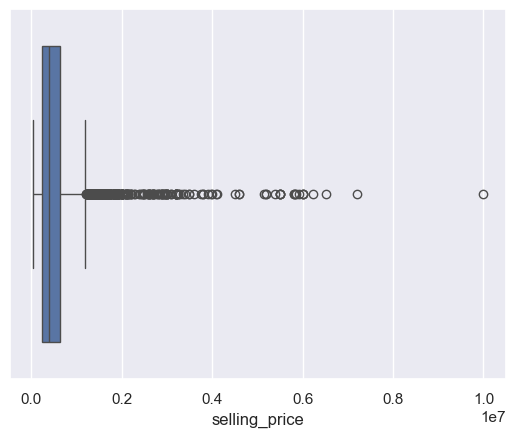

In [106]:
sns.boxplot(df['selling_price'],orient = "y")
plt.show()

In [107]:
def no_outliers_df(df_name, col_name):
    Q1 = df_name[col_name].quantile(0.25)
    Q3 = df_name[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    no_outliers_df = df_name[(df_name[col_name] >= lower_bound) & (df_name[col_name] <= upper_bound)]
    return no_outliers_df

In [108]:
# for 'selling_price' outliers
no_outliers_df(df,'selling_price')

,company,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/l),engine(CC),max_power(bhp),seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.10,5.0
8122,Hyundai,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54,1396.0,88.73,5.0
8123,Hyundai,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,5.0


In [109]:
# for 'selling_price' outliers
df = no_outliers_df(df,'selling_price')

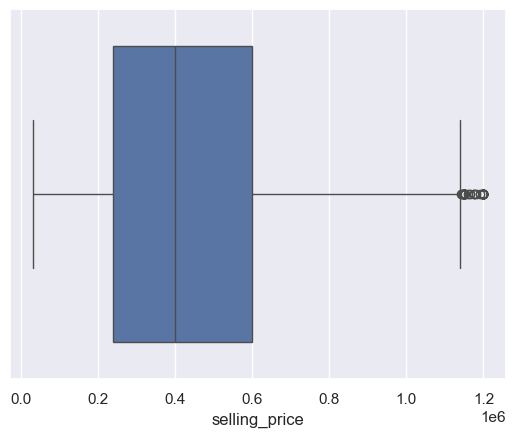

In [110]:
sns.boxplot(df['selling_price'],orient = "y")
plt.show()

#### km_driven

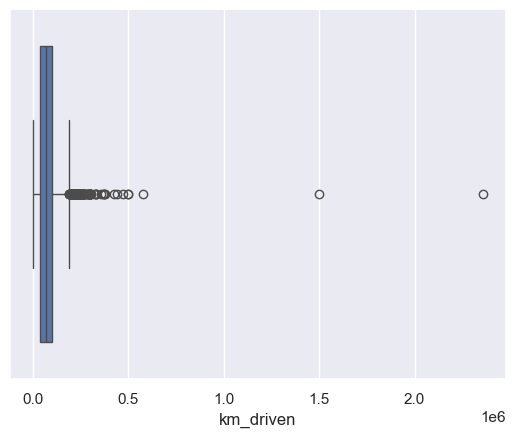

In [112]:
sns.boxplot(df['km_driven'],orient = "y")
plt.show()

In [113]:
# for 'km_driven' outliers
no_outliers_df(df,'km_driven')

,company,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/l),engine(CC),max_power(bhp),seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.10,5.0
8122,Hyundai,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54,1396.0,88.73,5.0
8123,Hyundai,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,5.0


In [114]:
# for 'km_driven' outliers
df = no_outliers_df(df,'km_driven')

#### mileage(km/l)

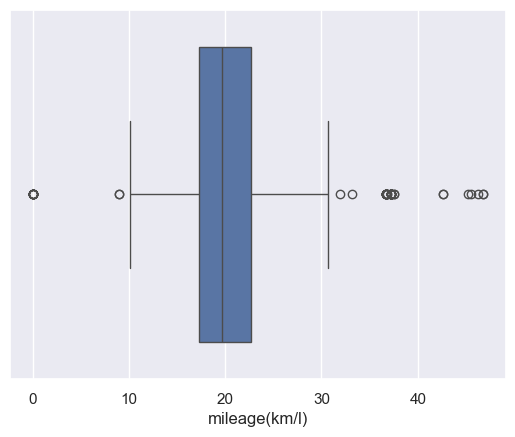

In [116]:
sns.boxplot(df['mileage(km/l)'],orient = "y")
plt.show()

In [117]:
# for 'mileage(km/l)' outliers
df = no_outliers_df(df,'mileage(km/l)')

### Categorical data

#### company

In [120]:
df['company'].value_counts()

company
Maruti           2112
Hyundai          1234
Mahindra          654
Tata              610
Ford              348
Honda             347
Toyota            220
Chevrolet         206
Renault           201
Volkswagen        165
Nissan             72
Skoda              61
Datsun             57
Fiat               43
BMW                15
Mercedes-Benz      10
Mitsubishi          6
Force               4
Audi                4
Ambassador          4
Daewoo              3
Kia                 1
Volvo               1
Opel                1
Peugeot             1
Isuzu               1
Name: count, dtype: int64

In [121]:
# droping lower than 10

In [122]:
company_list = df['company'].value_counts()[df['company'].value_counts() >= 10].index.tolist()

In [123]:
df[df['company'].isin(company_list)]['company'].value_counts()

company
Maruti           2112
Hyundai          1234
Mahindra          654
Tata              610
Ford              348
Honda             347
Toyota            220
Chevrolet         206
Renault           201
Volkswagen        165
Nissan             72
Skoda              61
Datsun             57
Fiat               43
BMW                15
Mercedes-Benz      10
Name: count, dtype: int64

In [124]:
df = df[df['company'].isin(company_list)]

In [125]:
df['fuel'].value_counts()

fuel
Diesel    3300
Petrol    2999
LPG         29
CNG         27
Name: count, dtype: int64

In [126]:
df['seller_type'].value_counts()

seller_type
Individual          5778
Dealer               551
Trustmark Dealer      26
Name: count, dtype: int64

In [127]:
df['transmission'].value_counts()

transmission
Manual       5984
Automatic     371
Name: count, dtype: int64

In [128]:
df['owner'].value_counts()

owner
First Owner             3864
Second Owner            1830
Third Owner              507
Fourth & Above Owner     154
Name: count, dtype: int64

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6355 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   company         6355 non-null   object 
 1   year            6355 non-null   int64  
 2   selling_price   6355 non-null   int64  
 3   km_driven       6355 non-null   int64  
 4   fuel            6355 non-null   object 
 5   seller_type     6355 non-null   object 
 6   transmission    6355 non-null   object 
 7   owner           6355 non-null   object 
 8   mileage(km/l)   6355 non-null   float64
 9   engine(CC)      6355 non-null   float64
 10  max_power(bhp)  6355 non-null   float64
 11  seats           6355 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 645.4+ KB


In [130]:
df.to_csv('cleaned_data_cars_selling_v3.csv', index=False)

## Encoding categorical data

In [132]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [133]:
df['company_encoded'] = encoder.fit_transform(df['company'])
df['fuel_encoded'] = encoder.fit_transform(df['fuel'])
df['seller_type_encoded'] = encoder.fit_transform(df['seller_type'])
df['transmission_encoded'] = encoder.fit_transform(df['transmission'])
df['owner_encoded'] = encoder.fit_transform(df['owner'])

In [134]:
df[['company_encoded','company']].drop_duplicates()

,company_encoded,company
0,8,Maruti
1,12,Skoda
2,5,Honda
3,6,Hyundai
8,14,Toyota
9,4,Ford
10,11,Renault
15,7,Mahindra
24,13,Tata
27,1,Chevrolet


In [135]:
df[['fuel_encoded','fuel']].drop_duplicates()

,fuel_encoded,fuel
0,1,Diesel
2,3,Petrol
6,2,LPG
402,0,CNG


In [136]:
df[['seller_type_encoded','seller_type']].drop_duplicates()

,seller_type_encoded,seller_type
0,1,Individual
42,0,Dealer
376,2,Trustmark Dealer


In [137]:
df[['transmission_encoded','transmission']].drop_duplicates()

,transmission_encoded,transmission
0,1,Manual
44,0,Automatic


In [138]:
df[['owner_encoded','owner']].drop_duplicates()

,owner_encoded,owner
0,0,First Owner
1,2,Second Owner
2,3,Third Owner
123,1,Fourth & Above Owner


In [139]:
df[['owner_encoded','owner']].drop_duplicates()

,owner_encoded,owner
0,0,First Owner
1,2,Second Owner
2,3,Third Owner
123,1,Fourth & Above Owner


In [226]:
df

,company,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/l),engine(CC),max_power(bhp),seats,company_encoded,fuel_encoded,seller_type_encoded,transmission_encoded,owner_encoded
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,8,1,1,1,0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,12,1,1,1,2
2,Honda,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,5,3,1,1,3
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,6,1,1,1,0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,8,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.10,5.0,8,3,1,1,2
8122,Hyundai,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54,1396.0,88.73,5.0,6,1,1,1,2
8123,Hyundai,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0,6,3,1,1,0
8124,Hyundai,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,5.0,6,1,1,1,1


## encoded dataframe

In [141]:
x = df.drop(['company',"selling_price",'fuel','seller_type','transmission', 'owner'],axis=1)

In [142]:
x.head()

,year,km_driven,mileage(km/l),engine(CC),max_power(bhp),seats,company_encoded,fuel_encoded,seller_type_encoded,transmission_encoded,owner_encoded
0,2014,145500,23.40,1248.0,74.00,5.0,8,1,1,1,0
1,2014,120000,21.14,1498.0,103.52,5.0,12,1,1,1,2
2,2006,140000,17.70,1497.0,78.00,5.0,5,3,1,1,3
3,2010,127000,23.00,1396.0,90.00,5.0,6,1,1,1,0
4,2007,120000,16.10,1298.0,88.20,5.0,8,3,1,1,0


In [143]:
y = df["selling_price"]

In [144]:
y.head()

0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64

## Scaling Numerical data

In [146]:
from sklearn.preprocessing import StandardScaler

In [147]:
Scaler = StandardScaler()
Target_scaler = StandardScaler()

In [148]:
x_scaled = Scaler.fit_transform(x)
x_scaled

array([[ 0.15679185,  1.89125698,  0.95198146, ...,  0.28508999,
         0.24899531, -0.76977708],
       [ 0.15679185,  1.24949071,  0.3482701 , ...,  0.28508999,
         0.24899531,  1.06412483],
       [-1.82365478,  1.7528368 , -0.57065339, ...,  0.28508999,
         0.24899531,  1.98107578],
       ...,
       [-0.09076398,  0.99781766, -0.35695026, ...,  0.28508999,
         0.24899531, -0.76977708],
       [-1.57609895,  1.2243234 , -0.81106942, ...,  0.28508999,
         0.24899531,  0.14717387],
       [-1.0809873 ,  1.24949071, -0.14324712, ...,  0.28508999,
         0.24899531, -0.76977708]])

In [149]:
y_scaled = Target_scaler.fit_transform(y.values.reshape(-1,1))
y_scaled

array([[ 0.05947938],
       [-0.2611436 ],
       [-1.1107945 ],
       ...,
       [-0.46153296],
       [-1.2029736 ],
       [-0.21305015]])

In [150]:
import joblib
joblib.dump(Scaler, 'Scaler.pkl')
joblib.dump(Target_scaler, 'Target_scaler.pkl')

['Target_scaler.pkl']

## Splitting training data

In [152]:
from sklearn.model_selection import train_test_split

In [153]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled,y_scaled,test_size=0.2,random_state=42)

## Building pipelines for models

In [155]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [156]:
lr = LinearRegression()
rfr = RandomForestRegressor()
svr = SVR()

In [162]:
param1 = {}
param1['regression'] = [lr]

param2 = {}
param2['regression__n_estimators'] = [100, 200, 300]
param2['regression__max_depth'] = [5, 10, 20, 30]
param2['regression__min_samples_split'] = [2, 5, 10]
param2['regression__min_samples_leaf'] = [1, 2, 4]
param2['regression__max_features'] = ['auto', 'sqrt', 'log2']
param2['regression__random_state'] = [42]
param2['regression'] = [rfr]

param3 = {}
param3['regression__C'] = [0.01, 0.1, 1, 10]
param3['regression__kernel'] = ['linear', 'rbf',"poly"]
param3['regression__gamma'] = ['scale', 'auto']
param3['regression__degree'] = [2, 3, 4 ]
param3['regression__epsilon'] = [0.1, 0.2]
param3['regression'] = [svr]



In [164]:
pipeline = Pipeline([('regression', lr)])
params = [param1, param2, param3]

In [166]:
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(pipeline,params, cv=5, n_jobs= -1 , scoring= 'r2' )


In [168]:
import time
start_time = time.time()

In [170]:
gs.fit(x_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
540 fits failed out of a total of 2345.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
182 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('regression', LinearRegression())]),
             n_jobs=-1,
             param_grid=[{'regression': [LinearRegression()]},
                         {'regression': [RandomForestRegressor()],
                          'regression__max_depth': [5, 10, 20, 30],
                          'regression__max_features': ['auto', 'sqrt', 'log2'],
                          'regression__min_samples_leaf': [1, 2, 4],
                          'regression__min_samples_split': [2, 5, 10],
                          'regression__n_estimators': [100, 200, 300],
                          'regression__random_state': [42]},
                         {'regression': [SVR()],
                          'regression__C': [0.01, 0.1, 1, 10],
                          'regression__degree': [2, 3, 4],
                          'regression__epsilon': [0.1, 0.2],
                          'regression__gamma': ['scale', 'auto'],
                          'regression__kernel': ['linear', 'rbf', 'poly']}],
             scoring='r2')

In [172]:
finish_time = time.time()
total_time = finish_time - start_time
print(total_time / 60)

3.485789171854655


In [174]:
gs.best_params_

{'regression': RandomForestRegressor(),
 'regression__max_depth': 20,
 'regression__max_features': 'sqrt',
 'regression__min_samples_leaf': 1,
 'regression__min_samples_split': 5,
 'regression__n_estimators': 300,
 'regression__random_state': 42}

In [176]:
gs.best_score_

0.894383686437968

In [212]:
bsmodel = gs.best_estimator_

In [269]:
joblib.dump(bsmodel,'Model.pkl')

['Model.pkl']

In [214]:
y_pre = bsmodel.predict(x_test)

In [224]:
from sklearn.metrics import r2_score, mean_absolute_error
r2_score(y_test,y_pre)

0.8891913732261967

In [222]:
mean_absolute_error(y_test,y_pre)

0.23609682503802304

In [204]:
my_model = joblib.load("Model.pkl")

In [250]:
x_train

array([[-0.58587564,  1.50116375, -1.5590304 , ...,  0.28508999,
         0.24899531,  1.06412483],
       [-0.58587564, -0.00887452, -0.92860615, ...,  0.28508999,
         0.24899531, -0.76977708],
       [-1.57609895,  0.24279853, -1.87958511, ...,  0.28508999,
         0.24899531,  1.06412483],
       ...,
       [-0.09076398,  0.24279853,  0.95198146, ...,  0.28508999,
         0.24899531,  0.14717387],
       [-1.0809873 ,  0.49447157, -1.5590304 , ...,  0.28508999,
         0.24899531,  1.06412483],
       [-0.09076398,  1.24949071, -1.82883061, ...,  0.28508999,
         0.24899531,  1.06412483]])

In [252]:
x.iloc[0].tolist()

[2014.0, 145500.0, 23.4, 1248.0, 74.0, 5.0, 8.0, 1.0, 1.0, 1.0, 0.0]

In [254]:
input_data = np.array([[2014.0, 145500.0, 23.4, 1248.0, 74.0, 5.0, 8.0, 1.0, 1.0, 1.0, 0.0]])

In [256]:
input_data_scaled = Scaler.transform(input_data)
input_data_scaled

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 0.15679185,  1.89125698,  0.95198146, -0.29472014, -0.39384527,
        -0.41509627,  0.05756023, -0.94175788,  0.28508999,  0.24899531,
        -0.76977708]])

In [264]:
y

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8121    260000
8122    475000
8123    320000
8124    135000
8125    382000
Name: selling_price, Length: 6355, dtype: int64

In [262]:
pred_scaled = my_model.predict(input_data_scaled)

In [267]:
Target_scaler.inverse_transform(pred_scaled.reshape(-1,1))

array([[493312.95330742]])

In [182]:
joblib.__version__

'1.4.2'

In [200]:
pd.__version__# pandas

'2.2.2'

In [202]:
np.__version__# numpy


'1.26.4'

In [1]:
import streamlit as st

In [2]:
import streamlit as st
import numpy as np
import pandas as pd
import plotly.express as px
import joblib

In [4]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import plotly
plotly.__version__

'6.3.0'

In [2]:
import joblib
joblib.__version__

'1.5.2'

In [3]:
import streamlit
streamlit.__version__

'1.51.0'